# Phân tích Khám phá Dữ liệu Churn Khách hàng (Customer Churn EDA)

**Mô tả dự án:**  
Dự án thực hiện Phân tích Khám phá Dữ liệu (EDA) một cách cô đọng và trực quan cho bài toán dự báo tỷ lệ rời bỏ dịch vụ của khách hàng (Customer Churn) từ cuộc thi Kaggle Playground Series S6E3.

**Mục tiêu chính:**  
- Đánh giá toàn diện chất lượng dữ liệu (missing values, duplicates) và cấu trúc của tập dữ liệu.
- Đo lường mức độ mất cân bằng của biến mục tiêu (`Churn`) phục vụ cho việc thiết lập chiến lược kiểm định.
- Khảo sát sự ảnh hưởng trực tiếp của các biến định tính và định lượng lên tỷ lệ rời bỏ của khách hàng thông qua phân tích phân phối và ma trận tương quan.
- So sánh phân phối đặc trưng giữa hai tập Train và Test để kịp thời phát hiện hiện tượng trôi dạt dữ liệu (data drift).

**Định hướng kết quả:**  
Cung cấp các kết luận phân tích cụ thể để định hình chiến lược tiền xử lý dữ liệu (preprocessing), thiết kế đặc trưng (feature engineering) và xây dựng mô hình học máy đạt hiệu quả tối ưu nhất.

## Thành viên nhóm 14
| Tên          | Mã số sinh viên    |
|----------------|--------------|
| Nguyễn Lan Anh       | 24280006      |
| Lê Văn Đức (Trưởng nhóm) | 24280010|
| Trần Quang Huy| 24280015|
| Phạm Tiến Phát    | 24280018 | 
|    Hoàng Gia Bảo | 24280049      |
| Đặng Hoàng Khang| 24280076|
| Nguyễn Tiến Phát | 24280093|


## Khai báo thư viện

In [10]:
# Setup: imports and display options
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import shutil


warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42
PLOT_SAMPLE_SIZE = 50000


## 1. Load các file dữ liệu
Kết hợp giữa lấy các files từ thư mục data/ trong thư mục làm việc hiện tại của dự án hoặc lấy trực tiếp từ kaggle nếu không tìm thấy files dữ liệu trong thư mục data/



In [5]:
# Optional: download data only if local CSV files are missing

candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([Path.cwd() / "data", Path("data"), Path("../data")])
existing_data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
local_data_dir = existing_data_dir or (Path.cwd().parent / "data" if Path.cwd().name.lower() == "eda" else Path.cwd() / "data")
if not (local_data_dir / "train.csv").exists():
    try:
        import kagglehub
    except ImportError as exc:
        raise ImportError(
            "data/train.csv is missing and kagglehub is not installed. "
            "Install it with `pip install kagglehub` or manually download the Kaggle CSV files into data/."
        ) from exc

    downloaded_path = None
    download_errors = []
    for download_func, slug in [
        (kagglehub.competition_download, "playground-series-s6e3"),
        (kagglehub.dataset_download, "sarvesh85/playground-series-s6e3"),
    ]:
        try:
            downloaded_path = Path(download_func(slug))
            break
        except Exception as exc:
            download_errors.append(f"{slug}: {exc}")

    if downloaded_path is None:
        raise RuntimeError("Could not download data. " + " | ".join(download_errors))

    local_data_dir.mkdir(exist_ok=True)
    for filename in ["train.csv", "test.csv", "sample_submission.csv"]:
        source = downloaded_path / filename
        if source.exists():
            shutil.copy2(source, local_data_dir / filename)

print("Data directory ready.")
print(sorted(path.name for path in local_data_dir.glob("*.csv")))


Data directory ready.
['sample_submission.csv', 'test.csv', 'train.csv']


## Thống kê sơ bộ và hiển thị các files dữ liệu

In [ ]:
# Load train/test/sample files and show the first rows
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv") if (data_dir / "test.csv").exists() else None
sample_submission = (
    pd.read_csv(data_dir / "sample_submission.csv")
    if (data_dir / "sample_submission.csv").exists()
    else None
)

file_summary = pd.DataFrame({
    "file": ["train.csv", "test.csv", "sample_submission.csv"],
    "rows": [len(train), len(test) if test is not None else np.nan, len(sample_submission) if sample_submission is not None else np.nan],
    "columns": [train.shape[1], test.shape[1] if test is not None else np.nan, sample_submission.shape[1] if sample_submission is not None else np.nan],
})

display(file_summary)
display(train.head())


,file,rows,columns
0,train.csv,594194,21
1,test.csv,254655,20
2,sample_submission.csv,254655,2


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


## Tổng quan về Bộ Dữ liệu

### 1. Vai trò của các file dữ liệu
* **`train.csv`**: Tập dữ liệu huấn luyện (Training Set). Chứa thông tin chi tiết của khách hàng cùng nhãn mục tiêu `Churn`. Được sử dụng để phân tích khám phá dữ liệu (EDA), xử lý đặc trưng và huấn luyện các mô hình học máy.
* **`test.csv`**: Tập dữ liệu kiểm thử (Test Set). Chứa các thông tin tương tự như tập train nhưng đã bị ẩn cột mục tiêu `Churn`. Được dùng để đưa vào mô hình đã huấn luyện nhằm dự đoán kết quả cuối cùng.
* **`sample_submission.csv`**: File định dạng nộp bài mẫu của Kaggle. Chứa hai cột là `id` và `Churn` (xác suất hoặc nhãn dự báo của khách hàng rời đi) để hướng dẫn cấu trúc nộp bài chuẩn.

---

### 2. Ý nghĩa các cột trong file `train.csv`

| Tên cột | Ý nghĩa | Kiểu dữ liệu / Giá trị |
| :--- | :--- | :--- |
| **`id`** | Mã định danh duy nhất của mỗi khách hàng. | Số nguyên (Cần loại bỏ khi huấn luyện) |
| **`gender`** | Giới tính của khách hàng. | `Male` (Nam) / `Female` (Nữ) |
| **`SeniorCitizen`** | Khách hàng có phải là người lớn tuổi (người già) hay không. | `1` (Có) / `0` (Không) |
| **`Partner`** | Khách hàng có đối tác / đã kết hôn hay không. | `Yes` / `No` |
| **`Dependents`** | Khách hàng có người phụ thuộc (con cái, cha mẹ...) hay không. | `Yes` / `No` |
| **`tenure`** | Số tháng khách hàng đã gắn bó sử dụng dịch vụ của công ty. | Số nguyên |
| **`PhoneService`** | Khách hàng có đăng ký dịch vụ điện thoại hay không. | `Yes` / `No` |
| **`MultipleLines`** | Khách hàng có sử dụng nhiều đường dây điện thoại hay không. | `Yes` / `No` / `No phone service` |
| **`InternetService`** | Loại hình kết nối mạng Internet của khách hàng. | `DSL` / `Fiber optic` / `No` |
| **`OnlineSecurity`** | Khách hàng có đăng ký dịch vụ bảo mật trực tuyến hay không. | `Yes` / `No` / `No internet service` |
| **`OnlineBackup`** | Khách hàng có đăng ký dịch vụ sao lưu dữ liệu trực tuyến hay không. | `Yes` / `No` / `No internet service` |
| **`DeviceProtection`** | Khách hàng có đăng ký dịch vụ bảo hiểm/bảo vệ thiết bị hay không. | `Yes` / `No` / `No internet service` |
| **`TechSupport`** | Khách hàng có đăng ký dịch vụ hỗ trợ kỹ thuật chuyên sâu hay không. | `Yes` / `No` / `No internet service` |
| **`StreamingTV`** | Khách hàng có sử dụng dịch vụ truyền hình trực tuyến hay không. | `Yes` / `No` / `No internet service` |
| **`StreamingMovies`** | Khách hàng có sử dụng dịch vụ xem phim trực tuyến hay không. | `Yes` / `No` / `No internet service` |
| **`Contract`** | Loại hợp đồng dịch vụ hiện tại của khách hàng. | `Month-to-month` / `One year` / `Two year` |
| **`PaperlessBilling`** | Khách hàng có nhận hóa đơn điện tử không dùng giấy hay không. | `Yes` / `No` |
| **`PaymentMethod`** | Phương thức thanh toán cước phí hàng tháng của khách hàng. | `Electronic check` / `Mailed check` / `Bank transfer (automatic)` / `Credit card (automatic)` |
| **`MonthlyCharges`** | Số tiền cước phí mà khách hàng phải trả hàng tháng. | Số thực (USD) |
| **`TotalCharges`** | Tổng số tiền lũy kế khách hàng đã chi trả kể từ khi bắt đầu dịch vụ. | Số thực (USD) |
| **`Churn`** | Khách hàng đã rời bỏ dịch vụ hay chưa. | **Biến mục tiêu (Target)**: `Yes` / `No` |


## 2. Kiểm tra chất lượng bộ dữ liệu
### Mục đích: Kiểm tra chất lượng dữ liệu (Data Quality Checks)

Đoạn code này thực hiện kiểm tra và đánh giá toàn diện tính toàn vẹn của dữ liệu đầu vào (`train.csv`, `test.csv`) trước khi tiến hành phân tích sâu hoặc huấn luyện mô hình. 

**Các nội dung kiểm tra cốt lõi bao gồm:**
* **Xác định quy mô hệ thống:** Thống kê số lượng dòng và cột của cả hai tập Train và Test để đảm bảo dữ liệu được tải lên đầy đủ.
* **Kiểm tra tính toàn vẹn (Data Integrity):** Đếm tổng số ô bị khuyết thiếu (`missing_cells`) và phát hiện các dòng trùng lặp (`duplicated_rows`) nhằm lên phương án làm sạch dữ liệu nếu cần.
* **Kiểm tra tính duy nhất của ID:** Đảm bảo cột khóa chính (`id`) không bị lặp lại để tránh hiện tượng nhiễu thông tin khách hàng.
* **Xác thực cấu trúc biến mục tiêu:** Kiểm tra sự tồn tại và các giá trị duy nhất của biến mục tiêu `Churn`.
* **So sánh cấu trúc thuộc tính:** Đối chiếu danh sách các cột giữa tập Train và Test nhằm phát hiện sớm sự bất thường hoặc lệch pha về cấu trúc (ví dụ: xác nhận tập Test chỉ thiếu duy nhất cột mục tiêu `Churn`).

In [ ]:
# Data quality checks
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv") if (data_dir / "test.csv").exists() else None
sample_submission = (
    pd.read_csv(data_dir / "sample_submission.csv")
    if (data_dir / "sample_submission.csv").exists()
    else None
)

expected_target = "Churn"
missing_by_column = train.isna().sum().sort_values(ascending=False)
quality_summary = pd.Series({
    "train_rows": len(train),
    "train_columns": train.shape[1],
    "test_rows": len(test) if test is not None else np.nan,
    "test_columns": test.shape[1] if test is not None else np.nan,
    "missing_cells_train": int(train.isna().sum().sum()),
    "duplicated_rows_train": int(train.duplicated().sum()),
    "duplicated_id_train": int(train["id"].duplicated().sum()) if "id" in train else np.nan,
    "target_unique_values": ", ".join(map(str, sorted(train[expected_target].unique()))) if expected_target in train else "missing",
})

train_only_columns = sorted(set(train.columns) - set(test.columns)) if test is not None else []
test_only_columns = sorted(set(test.columns) - set(train.columns)) if test is not None else []

display(quality_summary.to_frame("value"))
display(pd.DataFrame({"train_only_columns": pd.Series(train_only_columns), "test_only_columns": pd.Series(test_only_columns)}))
display(missing_by_column[missing_by_column > 0].to_frame("missing_count"))


,value
train_rows,594194
train_columns,21
test_rows,254655
test_columns,20
missing_cells_train,0
duplicated_rows_train,0
duplicated_id_train,0
target_unique_values,"No, Yes"


,train_only_columns,test_only_columns
0,Churn,NaN


,missing_count


### Tổng quan cấu trúc dữ liệu (Dataset Overview)

Bảng thống kê sơ bộ về kích thước và chất lượng dữ liệu giữa hai tập **Train** và **Test**:

* **Quy mô dữ liệu:** * Tập Train gồm **594,194 dòng** và **21 cột**.
  * Tập Test gồm **254,655 dòng** và **20 cột** (ít hơn 1 cột do không chứa biến mục tiêu).
* **Kiểm tra biến mục tiêu (`target_unique_values`):** Biến dự báo `Churn` nằm trong tập Train với 2 giá trị phân loại là `No` và `Yes`.
* **Chất lượng dữ liệu (Tập Train):**
  * Không có ô dữ liệu bị khuyết thiếu (`missing_cells_train = 0`).
  * Không có dòng trùng lặp (`duplicated_rows_train = 0`).
  * Không có ID bị lặp lại (`duplicated_id_train = 0`).
* **Sự khác biệt về thuộc tính:** Cột `Churn` chỉ xuất hiện ở tập Train (`train_only_columns`), tập Test không có (`NaN`), hoàn toàn phù hợp với logic của bài toán dự báo trên Kaggle.

## 3.Phân tích phân phối biến mục tiêu (Target Distribution)

### Mục đích
* Kiểm tra tỷ lệ phân bố giữa các lớp của biến mục tiêu `Churn` (`Yes` và `No`) trong tập huấn luyện.
* Xác định xem dữ liệu có rơi vào trạng thái mất cân bằng mẫu (Imbalanced Data) hay không để định hình chiến lược phân tách tập dữ liệu (Validation strategy) và lựa chọn hàm mất mát phù hợp khi huấn luyện mô hình.

,Churn,count,percent
0,No,460377,77.479241
1,Yes,133817,22.520759


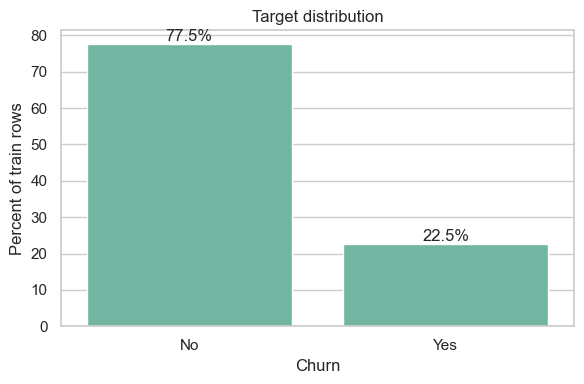

In [ ]:
# Target distribution
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

churn_counts = train["Churn"].value_counts().rename_axis("Churn").reset_index(name="count")
churn_counts["percent"] = churn_counts["count"] / len(train) * 100

display(churn_counts)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=churn_counts, x="Churn", y="percent", ax=ax)
ax.set_title("Target distribution")
ax.set_ylabel("Percent of train rows")
ax.set_xlabel("Churn")
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(f"{height:.1f}%", (patch.get_x() + patch.get_width() / 2, height), ha="center", va="bottom")
plt.tight_layout()
plt.show()



* **Kết quả:** Nhóm khách hàng ở lại (`No`) chiếm đa số với **77.5%** ($460,377$ dòng), trong khi nhóm khách hàng rời bỏ dịch vụ (`Yes`) chỉ chiếm **22.5%** ($133,817$ dòng).
* **Kết luận cho hệ thống:**
  * **Đánh giá:** Tập dữ liệu có hiện tượng **mất cân bằng mẫu** ở mức độ vừa phải (tỷ lệ gần $3.5 : 1$).
  * **Định hướng chia dữ liệu:** Bắt buộc sử dụng kỹ thuật phân tầng (Stratified K-Fold Validation) khi chia tập Train/Validation để giữ nguyên tỷ lệ $22.5\%$ này trên mọi Fold.
  * **Hướng xử lý mô hình:** Khi thiết kế tính năng (Feature Engineering), cần tập trung khai thác các nhóm biến có tính phân hóa mạnh (như cụm heatmap hay service gap đã phân tích) giúp mô hình dễ dàng bắt được đặc trưng của nhóm thiểu số (`Yes`), tránh hiện tượng mô hình bị thiên lệch (bias) về nhóm số đông (`No`).

## 4. Phân tích bản số lượng nhóm và giá trị áp đảo (Categorical Cardinality & Dominant Categories)

### Mục đích
* Khảo sát các thuộc tính phân loại (categorical features) để xác định số lượng giá trị duy nhất (`unique_values`) của từng biến (đo lường tính Cardinality).
* Phát hiện các nhóm chiếm tỷ lệ áp đảo (`top_value_percent`) hoặc các nhóm quá hiếm gặp (`rare_values_under_1pct`) nhằm định hình phương án mã hóa biến (Encoding) và xử lý dữ liệu trước khi đưa vào mô hình học máy.

In [ ]:
# Categorical cardinality and dominant categories
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

categorical_cols = [col for col in train.select_dtypes(include="object").columns if col != "Churn"]
rows = []
for col in categorical_cols:
    counts = train[col].value_counts(dropna=False)
    rows.append({
        "feature": col,
        "unique_values": train[col].nunique(dropna=False),
        "top_value": counts.index[0],
        "top_value_percent": counts.iloc[0] / len(train) * 100,
        "rare_values_under_1pct": int((counts / len(train) < 0.01).sum()),
    })

cat_summary = pd.DataFrame(rows).sort_values(["unique_values", "feature"])
display(cat_summary)


,feature,unique_values,top_value,top_value_percent,rare_values_under_1pct
2,Dependents,2,No,69.735137,0
13,PaperlessBilling,2,Yes,61.525192,0
1,Partner,2,Yes,52.096453,0
3,PhoneService,2,Yes,93.890716,0
0,gender,2,Female,50.276172,0
12,Contract,3,Month-to-month,50.306466,0
8,DeviceProtection,3,No,41.632362,0
5,InternetService,3,Fiber optic,45.841257,0
4,MultipleLines,3,No,47.692168,0
7,OnlineBackup,3,No,42.087769,0



* **Kết quả:**
  * **Cardinality thấp:** Tất cả các thuộc tính đều có số lượng nhóm rất nhỏ, dao động từ 2 đến 4 nhóm (ví dụ: `gender` có 2 nhóm, `Contract` có 3 nhóm, `PaymentMethod` có 4 nhóm).
  * **Không có giá trị hiếm:** Cột `rare_values_under_1pct` bằng `0` ở tất cả các thuộc tính, chứng tỏ không có nhóm nào xuất hiện ít hơn 1% tổng số dòng dữ liệu.
  * **Giá trị áp đảo:** Biến `PhoneService` có hiện tượng mất cân bằng cực hạn khi nhóm `Yes` chiếm tới **93.89%**. Các biến còn lại có sự phân phối giữa các nhóm tương đối đều hoặc vừa phải.
* **Kết luận cho hệ thống:**
  * **Chiến lược Encoding:** Vì số lượng nhóm của mỗi biến rất ít ($\le 4$), có thể áp dụng phương pháp **One-Hot Encoding** một cách an toàn cho toàn bộ các biến này mà không sợ làm bùng nổ số lượng cột (Curse of Dimensionality).
  * **Xử lý nhóm hiếm:** Không cần thực hiện các kỹ thuật gộp nhóm hiếm (như Rare Label Encoding) vì không tồn tại nhóm nào dưới 1%.
  * **Lưu ý mô hình:** Cột `PhoneService` có độ phân hóa cực kỳ thấp (hầu như ai cũng dùng). Cần đối chiếu thêm với biểu đồ tỉ lệ Churn để xem biến này có thực sự mang lại giá trị dự báo cho mô hình hay không, hoặc có thể xem xét loại bỏ nếu nó không tạo ra sự phân tách hành vi khách hàng.

## 5. Phân tích biên độ lệch tỷ lệ rời bỏ theo thuộc tính phân loại (Churn Rate Spread Analysis)

### Mục đích
* Đo lường sức mạnh phân hóa của từng thuộc tính phân loại bằng cách tính khoảng chênh lệch điểm phần trăm (`spread_pp`) giữa nhóm có tỷ lệ rời bỏ cao nhất (`highest_risk_rate`) và thấp nhất (`lowest_risk_rate`).
* Sắp xếp mức độ quan trọng của các biến định tính nhằm phục vụ trực tiếp cho việc lựa chọn đặc trưng (Feature Selection) và định hướng tạo ra các biến phái sinh mang tín hiệu mạnh cho mô hình dự báo.


In [ ]:
# Churn rate spread by categorical feature
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

train = train.assign(churn_flag=train["Churn"].eq("Yes").astype(int))
categorical_cols = [col for col in train.select_dtypes(include="object").columns if col != "Churn"]
rows = []
for col in categorical_cols:
    grouped = train.groupby(col, dropna=False)["churn_flag"].agg(churn_rate="mean", rows="size")
    grouped = grouped[grouped["rows"] >= 100]
    high = grouped.sort_values("churn_rate", ascending=False).iloc[0]
    low = grouped.sort_values("churn_rate", ascending=True).iloc[0]
    rows.append({
        "feature": col,
        "highest_risk_value": high.name,
        "highest_risk_rate": high["churn_rate"] * 100,
        "highest_risk_rows": int(high["rows"]),
        "lowest_risk_value": low.name,
        "lowest_risk_rate": low["churn_rate"] * 100,
        "lowest_risk_rows": int(low["rows"]),
        "spread_pp": (high["churn_rate"] - low["churn_rate"]) * 100,
    })

risk_spread = pd.DataFrame(rows).sort_values("spread_pp", ascending=False)
display(risk_spread.round({"highest_risk_rate": 2, "lowest_risk_rate": 2, "spread_pp": 2}))


,feature,highest_risk_value,highest_risk_rate,highest_risk_rows,lowest_risk_value,lowest_risk_rate,lowest_risk_rows,spread_pp
14,PaymentMethod,Electronic check,48.91,215372,Credit card (automatic),6.93,133705,41.97
12,Contract,Month-to-month,42.05,298918,Two year,1.00,186943,41.06
5,InternetService,Fiber optic,41.54,272386,No,1.43,140727,40.11
6,OnlineSecurity,No,40.61,289474,No internet service,1.43,140727,39.18
9,TechSupport,No,40.16,288571,No internet service,1.43,140727,38.73
7,OnlineBackup,No,39.10,250083,No internet service,1.43,140727,37.67
8,DeviceProtection,No,38.06,247377,No internet service,1.43,140727,36.63
11,StreamingMovies,No,29.93,212032,No internet service,1.43,140727,28.50
10,StreamingTV,No,29.74,213166,No internet service,1.43,140727,28.31
13,PaperlessBilling,Yes,31.94,365579,No,7.46,228615,24.48



* **Kết quả:**
  * **Top 3 biến có lực phân hóa mạnh nhất (Biên độ lệch $>40\%$):** * `PaymentMethod` dẫn đầu với khoảng lệch **41.97%** (nhóm thanh toán bằng *Electronic check* có tỷ lệ rời đi lên tới $48.91\%$, trong khi *Credit card (automatic)* chỉ có $6.93\%$).
    * `Contract` theo sát với khoảng lệch **41.06%** (nhóm hợp đồng ký theo tháng *Month-to-month* rủi ro rất cao $42.05\%$, ngược lại hợp đồng 2 năm *Two year* cực kỳ an toàn ở mức $1.00\%$).
    * `InternetService` đứng thứ ba với khoảng lệch **40.11%** (nhóm mạng cáp quang *Fiber optic* đối mặt rủi ro rời bỏ lên đến $41.54\%$).
  * **Nhóm tính năng phân hóa yếu:** Thuộc tính `gender` nằm ở cuối bảng với biên độ lệch gần như bằng không (**0.57%**), cho thấy tỷ lệ churn giữa Nam và Nữ đồng đều một cách tuyệt đối (khoảng $22\%$).
* **Kết luận cho hệ thống:**
  * **Đánh giá mức độ quan trọng (Feature Importance):** Các biến `PaymentMethod`, `Contract`, `InternetService`, cùng cụm tính năng bảo mật/kỹ thuật (`OnlineSecurity`, `TechSupport`...) là những biến bắt buộc phải giữ lại vì chúng chứa lượng thông tin cốt lõi để phân tách nhãn `Churn`.
  * **Xử lý biến yếu:** Cân nhắc loại bỏ hoàn toàn biến `gender` ra khỏi tập huấn luyện vì nó không mang lại bất kỳ giá trị phân tách hành vi nào cho các thuật toán học máy.
  * **Gợi ý Feature Engineering:** Dựa trên các nhóm rủi ro cao, có thể tạo thêm các biến chỉ báo tương tác (Interaction Features) như: kết hợp giữa nhóm dùng mạng cáp quang (`Fiber optic`) và đang trả tiền theo tháng (`Month-to-month`) để cô lập nhóm khách hàng có nguy cơ rời đi nghiêm trọng nhất.

## 6. Bản đồ tương quan giữa các biến định tính cơ bản và Churn (Categorical Correlation Heatmap)

### Mục đích
* Trực quan hóa toàn bộ mối quan hệ tuyến tính giữa các thuộc tính định tính (sau khi đã biến đổi tạm thời về dạng nhị phân 0 và 1) với biến mục tiêu `Churn` và với chính các cặp biến độc lập khác.
* Phát hiện sớm hiện tượng đa cộng tuyến (Multicollinearity) giữa các biến dự báo và sàng lọc các đặc trưng mang thông tin tương tự nhau nhằm tối ưu hóa hiệu năng cho các mô hình học máy phân loại.

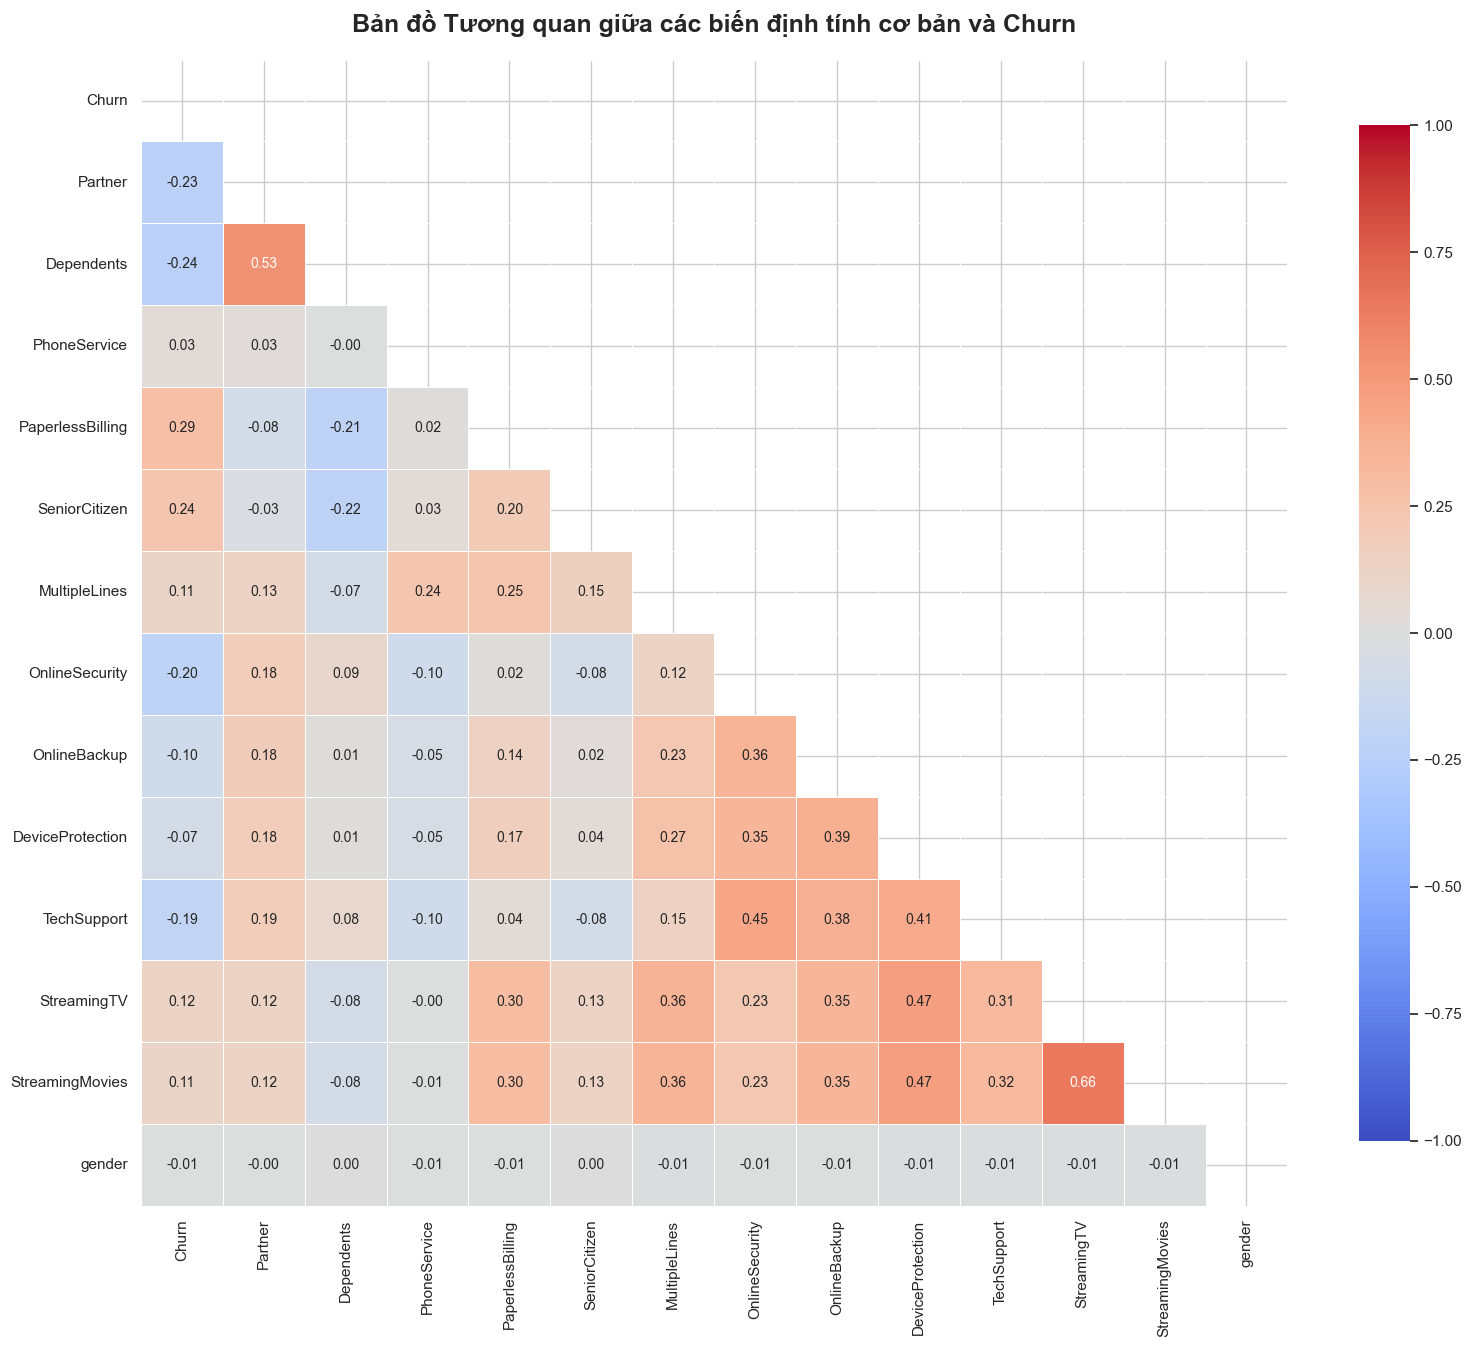

In [13]:
# 1. Tìm đường dẫn và tải dữ liệu train.csv
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
df_train_copy = pd.read_csv(data_dir / "train.csv")
# 2. Xử lý mã hóa các biến định tính nhị phân
binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'SeniorCitizen']
for col in binary_cols:
    df_train_copy[col] = df_train_copy[col].replace({'Yes': 1, 'No': 0})
df_train_copy['gender'] = df_train_copy['gender'].replace({'Male': 1, 'Female': 0})
# 3. Xử lý mã hóa các biến gần nhị phân (quy các nhãn "No service" về "No" rồi chuyển thành 0 và 1)
nearly_binary_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in nearly_binary_cols:
    df_train_copy[col] = df_train_copy[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    df_train_copy[col] = df_train_copy[col].replace({'Yes': 1, 'No': 0})
# 4. Tính toán ma trận tương quan giữa các biến định tính và Churn
cols_to_corr = binary_cols + nearly_binary_cols + ['gender']
corr_matrix = df_train_copy[cols_to_corr].astype(float).corr()
# 5. Vẽ bản đồ nhiệt tương quan (Heatmap) dạng tam giác dưới
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8},
    annot_kws={"size": 10}
)
plt.title('Bản đồ Tương quan giữa các biến định tính cơ bản và Churn', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


* **Kết quả:**
  * **Tương quan với nhãn Churn (Cột ngoài cùng bên trái):** * Thuộc tính `PaperlessBilling` ($0.29$) và `SeniorCitizen` ($0.24$) đồng biến (tương quan thuận) rõ rệt nhất với nguy cơ hủy dịch vụ.
    * Thuộc tính người phụ thuộc `Dependents` ($-0.24$) và có gia đình `Partner` ($-0.23$) mang đặc tính tỷ lệ nghịch (tương quan âm) mạnh nhất với hành vi rời đi.
  * **Cụm đa cộng tuyến (Tương quan nội bộ mạnh giữa các biến độc lập):**
    * Cặp dịch vụ giải trí trực tuyến `StreamingTV` và `StreamingMovies` có hệ số tương quan rất cao, đạt **0.66**.
    * Cặp trạng thái nhân khẩu học `Partner` và `Dependents` có hệ số tương quan tuyến tính đạt **0.53**.
    * Nhóm dịch vụ tiện ích bổ trợ Internet (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`) liên kết chặt chẽ chéo lẫn nhau với các hệ số dao động từ **0.35** đến **0.47**.
* **Kết luận cho hệ thống:**
  * **Xử lý đa cộng tuyến:** Do `StreamingTV` và `StreamingMovies` tương quan rất mạnh ($0.66$), khi đưa vào các mô hình tuyến tính (như Logistic Regression), có thể cân nhắc gộp chúng lại thành một biến đếm tổng hợp (ví dụ: `streaming_services_count`) để giảm độ nhiễu hệ thống.
  * **Tối ưu hóa cụm tiện ích:** Sự tương quan đồng đều ($0.35 \rightarrow 0.47$) trong cụm dịch vụ bảo mật/hỗ trợ kỹ thuật mở ra cơ hội tạo thêm một tính năng tích hợp dạng điểm số như `total_utility_services_signed` để đại diện cho mức độ cam kết gắn bó của khách hàng.
  * **Loại bỏ đặc trưng thừa:** Biến `gender` ($-0.01$) hoàn toàn không có bất kỳ mối liên hệ nào với biến mục tiêu hay các biến khác trong hệ thống. Việc drop cột này trước khi train mô hình là quyết định tối ưu.

## 7. Trực quan hóa tỷ lệ rời bỏ theo các thuộc tính phân loại chính (Categorical Churn Rate Visualizations)

### Mục đích
* Trực quan hóa tỷ lệ rời bỏ dịch vụ (`Churn rate (%)`) của từng nhóm đối tượng cụ thể trong các thuộc tính phân loại hàng đầu (được lọc ra từ bảng biên độ lệch trước đó).
* Giúp phát hiện trực quan và nhanh chóng các phân khúc khách hàng có nguy cơ rời dịch vụ cao đột biến (Hotspots) nhằm hỗ trợ đưa ra các nhận định logic phục vụ quá trình xây dựng mô hình học máy.


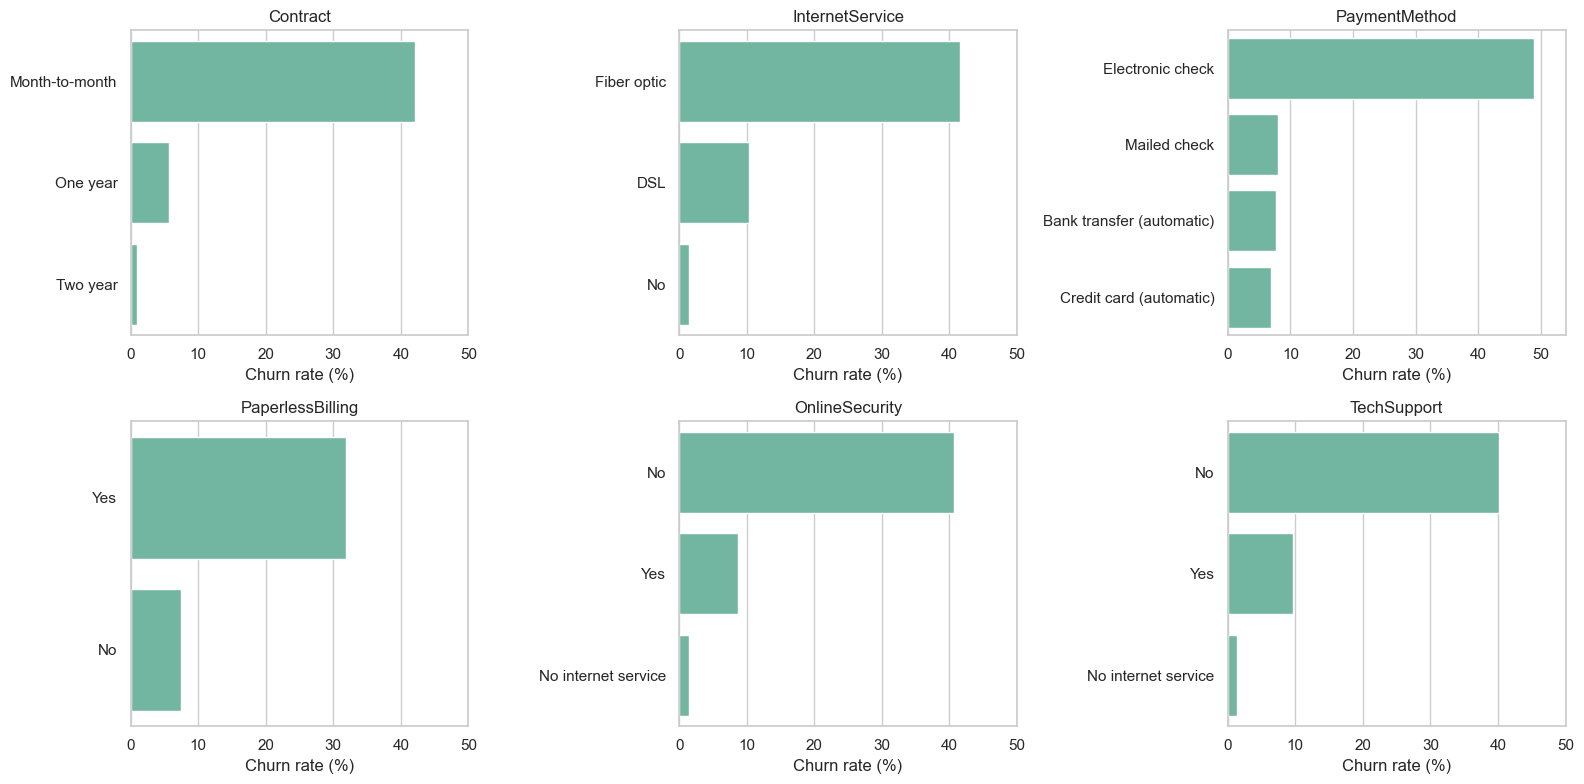

In [ ]:
# Plot churn rates for selected categorical features
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

train = train.assign(churn_flag=train["Churn"].eq("Yes").astype(int))
selected_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling",
    "OnlineSecurity",
    "TechSupport",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feature in zip(axes.ravel(), selected_features):
    plot_data = (
        train.groupby(feature, dropna=False)["churn_flag"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .reset_index(name="churn_rate")
    )
    sns.barplot(data=plot_data, y=feature, x="churn_rate", ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("Churn rate (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, max(50, plot_data["churn_rate"].max() + 5))
plt.tight_layout()
plt.show()



* **Kết quả:**
  * **Rủi ro nhóm dịch vụ lõi:** Khách hàng sử dụng hình thức thanh toán ngắn hạn theo từng tháng (`Month-to-month`), dùng mạng cáp quang (`Fiber optic`), hoặc thanh toán hóa đơn bằng séc điện tử (`Electronic check`) đều sở hữu tỷ lệ rời đi vượt trội, dao động rất cao từ **40% đến gần 50%**.
  * **Rủi ro từ việc thiếu dịch vụ bổ trợ:** Ở hai đồ thị `OnlineSecurity` và `TechSupport`, nhóm khách hàng chọn **"No"** (không đăng ký dịch vụ bảo mật hoặc hỗ trợ kỹ thuật) có tỷ lệ churn lên tới **40%**, trong khi các nhóm có đăng ký (`Yes`) hoặc không dùng internet đều duy trì tỷ lệ hủy dịch vụ cực kỳ thấp.
* **Kết luận cho hệ thống:**
  * **Xử lý đặc trưng phi tuyến:** Biểu đồ chứng minh mối quan hệ mang tính phân tách nhóm (Non-linear/Discretized) rất rõ ràng. Việc chuyển các thuộc tính này thành các biến định danh thông qua One-Hot Encoding sẽ giúp các mô hình (như Tree-based models hay Logistic Regression) dễ dàng tìm ra các ngưỡng phân tách tối ưu.
  * **Gợi ý Feature Engineering:** * Tạo biến cờ hiệu rủi ro cao (High-risk flag): Thiết lập biến nhị phân `is_high_risk_profile = 1` nếu khách hàng thỏa mãn đồng thời các điều kiện có tỷ lệ churn cao (ví dụ: `Contract == "Month-to-month"` VÀ `PaymentMethod == "Electronic check"`).
    * Nhóm gộp danh mục an toàn: Với các giá trị có tỷ lệ churn tương đồng và rất thấp (như nhóm `Two year` của biến Contract, hoặc nhóm `No internet service` của các biến tiện ích), mô hình vẫn phân tách tốt nếu giữ nguyên, nhưng có thể cân nhắc gộp nhãn nếu cần giảm chiều dữ liệu.

## 8. Ma trận tương quan giữa các biến số (Numerical Correlation Matrix)

### Mục đích
* Đo lường sức mạnh và chiều hướng của mối quan hệ tuyến tính (hệ số tương quan Pearson) giữa các thuộc tính số (`SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`) với biến mục tiêu `ChurnBinary`.
* Sàng lọc và phát hiện sớm hiện tượng đa cộng tuyến (Multicollinearity) giữa các biến độc lập dạng số để ngăn ngừa lỗi nhiễu hệ thống hoặc làm giảm hiệu năng của các mô hình tuyến tính.

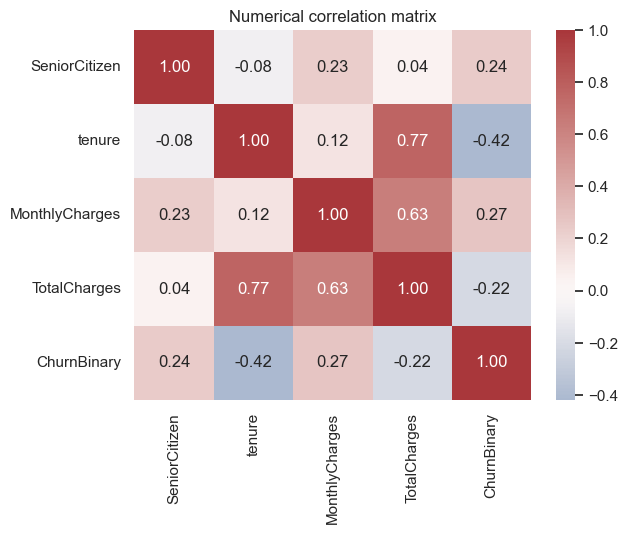

In [14]:
# Numeric summary and correlation with churn
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

# Tạo cột ChurnBinary (0 và 1) từ cột Churn
train = train.assign(ChurnBinary=train["Churn"].eq("Yes").astype(int))
numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

# Tính toán và hiển thị ma trận tương quan dưới dạng heatmap
corr_cols = numeric_cols + ["ChurnBinary"]
corr = train[corr_cols].corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Numerical correlation matrix")
plt.show()



* **Kết quả:**
  * **Tương quan với nhãn Churn (`ChurnBinary`):**
    * Thuộc tính `tenure` ($-0.42$) phản ánh mối tương quan nghịch mạnh nhất (khách hàng sử dụng dịch vụ càng nhiều tháng càng ít rời bỏ hệ thống).
    * Thuộc tính `MonthlyCharges` ($0.27$) và `SeniorCitizen` ($0.24$) mang mối tương quan thuận rõ rệt (cước phí hàng tháng càng cao hoặc khách hàng là người cao tuổi thì nguy cơ hủy dịch vụ càng lớn).
  * **Xác định hiện tượng đa cộng tuyến mạnh:**
    * Cặp biến `TotalCharges` và `tenure` có hệ số tương quan rất cao, đạt **0.77**.
    * Cặp biến `TotalCharges` và `MonthlyCharges` cũng giữ mối tương quan thuận mạnh, đạt **0.63**.
* **Kết luận cho hệ thống:**
  * **Xử lý đa cộng tuyến:** Biến `TotalCharges` (Tổng chi phí tích lũy) phụ thuộc tuyến tính rất mạnh vào cả thời gian gắn bó (`tenure`) lẫn cước phí tháng (`MonthlyCharges`). Để tránh gây nhiễu cho các thuật toán mẫn cảm với đa cộng tuyến (như Logistic Regression), cân nhắc loại bỏ biến `TotalCharges` hoặc áp dụng các phương pháp phạt (Ridge/Lasso Regularization).
  * **Gợi ý Feature Engineering:** * Tạo biến chênh lệch giá (Charge Residual): Tính toán chỉ số cước phí ước tính (`estimated_total = MonthlyCharges * tenure`) và đo khoảng lệch so với thực tế (`total_charge_gap = TotalCharges - estimated_total`) để tìm kiếm tín hiệu từ việc thay đổi gói cước giữa chừng.
    * Tạo biến phân nhóm (Binning): Chuyển đổi hai biến có lực phân hóa tốt là `tenure` và `MonthlyCharges` thành các biến phân nhóm (Tenure buckets, Monthly charge quartiles) để xây dựng ma trận mật độ rủi ro (Heatmap), giúp các mô hình dựa trên cây (Tree-based) bắt được quan hệ phi tuyến dễ dàng hơn.

## 9. Biểu đồ phân phối các biến số theo nhãn mục tiêu (Numeric Distribution Plots by Target)

### Mục đích
* Trực quan hóa hình dạng phân phối xác suất (thông qua Histplot kết hợp đường ước lượng mật độ nhân KDE) của các thuộc tính số giữa hai nhóm khách hàng: Ở lại (`Churn = No`) và Rời đi (`Churn = Yes`).
* Phát hiện các điểm gãy phân phối, các ngưỡng giá trị tới hạn và hành vi phi tuyến tính của dữ liệu số để định hình giải pháp làm sạch dữ liệu và tạo lập tính năng mới.

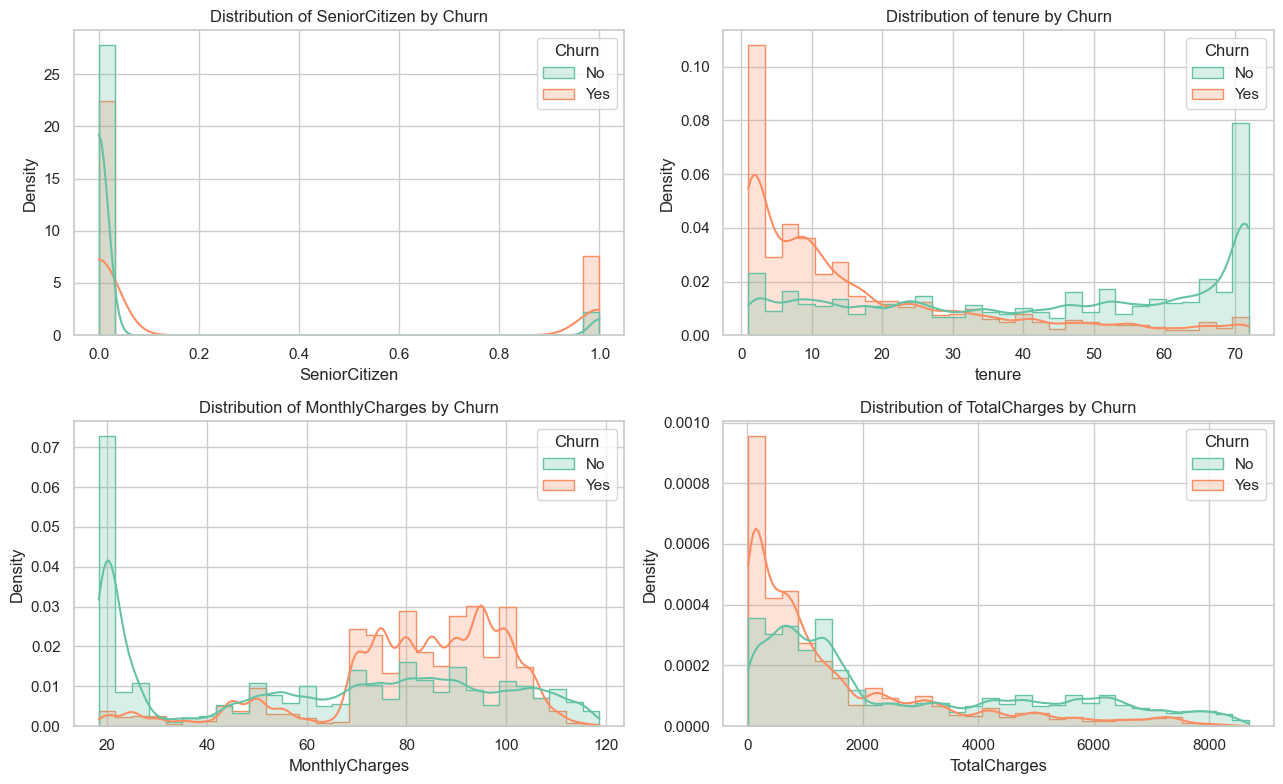

In [15]:
# Numeric distribution plots by target
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )

train = pd.read_csv(data_dir / "train.csv")
target_candidates = [col for col in ["Churn", "churn", "target", "Target"] if col in train.columns]
target_col = target_candidates[0] if target_candidates else train.columns[-1]
id_like_cols = [col for col in train.columns if col.lower() in {"id", "customerid", "customer_id"}]

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    if col in train.columns:
        train[col] = pd.to_numeric(train[col], errors="coerce")

numeric_cols = [col for col in train.select_dtypes(include=np.number).columns if col not in id_like_cols + [target_col]]
selected_cols = numeric_cols[:8]
if not selected_cols:
    raise ValueError("No numeric features were found for analysis.")


n_cols = 2
n_rows = int(np.ceil(len(selected_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4 * n_rows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, selected_cols):
    sns.histplot(data=train, x=col, hue=target_col, kde=True, bins=30, element="step", stat="density", common_norm=False, ax=ax)
    ax.set_title(f"Distribution of {col} by {target_col}")
for ax in axes[len(selected_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


* **Kết quả:**
  * **`tenure` (Thời gian gắn bó):** Xuất hiện sự phân tách cực hạn. Nhóm rời đi (`Yes`) tập trung mật độ cao nhất ở những tháng đầu tiên ($1 \rightarrow 5$ tháng) và giảm dần đều. Ngược lại, nhóm ở lại (`No`) có xu hướng tích tụ mạnh tại mốc lâu năm (khoảng $70 \rightarrow 72$ tháng).
  * **`MonthlyCharges` (Cước phí tháng):** Nhóm ở lại (`No`) tạo một đỉnh rất cao ở vùng giá rẻ (khoảng $20$). Trong khi đó, nhóm hủy dịch vụ (`Yes`) chiếm mật độ áp đảo ở phân khúc cước phí cao từ $70 \rightarrow 100$.
  * **`TotalCharges` (Tổng chi phí):** Cả hai nhóm đều lệch phải (Skewed right), nhưng nhóm rời đi dồn tích rất nhanh ở sát mốc $0$, phản ánh việc họ hủy dịch vụ ngay khi tổng số tiền bỏ ra chưa nhiều.
  * **`SeniorCitizen` (Người cao tuổi):** Bản chất là biến phân loại nhị phân ($0$ và $1$) được lưu ở dạng số. Nhóm người cao tuổi ($1.0$) có tỷ lệ diện tích cột màu cam (`Yes`) cao hơn hẳn so với tỷ lệ ở cột khách hàng trẻ ($0.0$).
* **Kết luận cho hệ thống:**
  * **Xử lý phân phối lệch:** Biến `TotalCharges` có phân phối lệch phải nghiêm trọng. Nên áp dụng phép biến đổi Logarithm (`np.log1p`) để thu hẹp khoảng cách phân tán, đưa biến về dạng phân phối chuẩn hơn, giúp tăng hiệu năng cho các mô hình tuyến tính hoặc mạng thần kinh.
  * **Gợi ý Feature Engineering:**
    * **Rời bỏ sớm (Early Churn Flag):** Tạo tính năng nhị phân `is_early_user = (tenure <= 5).astype(int)` để khoanh vùng trực tiếp nhóm phân phối nguy cơ cao nhất trên đồ thị `tenure`.
    * **Phân nhóm giá cước cao (High Charge Bin):** Tạo biến định danh dựa trên điểm gãy của đồ thị `MonthlyCharges` (ví dụ: `is_high_monthly_charge = (MonthlyCharges > 70).astype(int)`) nhằm cô lập phân khúc khách hàng đang phải gánh cước phí nặng - nhóm có mật độ rời đi vượt trội.

## 10. Biểu đồ nhiệt tương quan đa biến giữa Thời gian gắn bó và Chi phí hàng tháng (Bivariate Churn Heatmap Analysis)

### Mục đích
* Khảo sát mối quan hệ tương tác đồng thời giữa hai thuộc tính số có lực ảnh hưởng mạnh nhất đến nhãn mục tiêu: Thời gian gắn bó (`tenure`) và Chi phí hàng tháng (`MonthlyCharges`).
* Chia nhỏ dữ liệu thành các phân khúc ma trận mật độ (nhóm khoảng thời gian và phân vị chi phí) nhằm phát hiện các phân lớp phi tuyến tính phức tạp hoặc các điểm giao thoa có rủi ro rời đi cục bộ nghiêm trọng nhất (Hotspots).

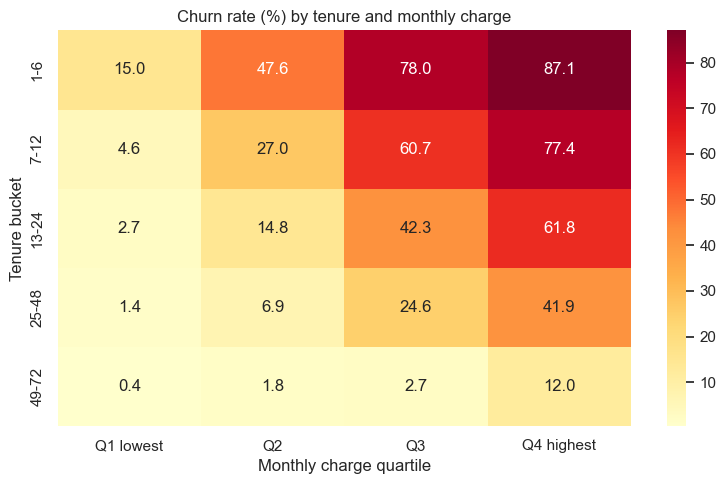

In [16]:
# Churn heatmap by tenure bucket and monthly charge quartile
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

train = train.assign(churn_flag=train["Churn"].eq("Yes").astype(int))
train["tenure_bucket"] = pd.cut(
    train["tenure"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=["1-6", "7-12", "13-24", "25-48", "49-72"],
    include_lowest=True,
)
train["monthly_charge_quartile"] = pd.qcut(
    train["MonthlyCharges"],
    q=4,
    labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"],
    duplicates="drop",
)

heatmap_data = (
    train.pivot_table(
        index="tenure_bucket",
        columns="monthly_charge_quartile",
        values="churn_flag",
        aggfunc="mean",
        observed=False,
    )
    .mul(100)
)


fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("Churn rate (%) by tenure and monthly charge")
ax.set_xlabel("Monthly charge quartile")
ax.set_ylabel("Tenure bucket")
plt.tight_layout()
plt.show()



* **Kết quả:**
  * **Điểm nóng rủi ro cực hạn (Góc trên cùng bên phải):** Nhóm khách hàng mới sử dụng dịch vụ (**1-6 tháng**) nhưng phải gánh mức cước phí cao nhất (**Q4 highest**) có tỷ lệ rời đi lên tới **87.1%**. Ngay cả ở mức cước phí Q3, tỷ lệ hủy dịch vụ của nhóm này cũng chạm mốc **78.0%**.
  * **Vùng an toàn trung thành (Góc dưới cùng bên trái):** Khách hàng lâu năm (**49-72 tháng**) và chi trả mức cước rẻ nhất (**Q1 lowest**) có tỷ lệ rời bỏ gần như bằng không, chỉ đạt **0.4%**.
  * **Tính chất tương tác:** Đồ thị thể hiện một xu hướng tuyến tính chéo rõ rệt. Khi dịch chuyển từ dưới lên trên (giảm thời gian gắn bó) hoặc dịch chuyển từ trái sang phải (tăng cước phí tháng), tỷ lệ rời bỏ đều tăng trưởng mạnh mẽ ở mọi phân khúc.
* **Kết luận cho hệ thống:**
  * **Sự cần thiết của Feature Interaction:** Biểu đồ chứng minh rằng sự kết hợp đồng thời giữa một biến tương quan âm mạnh (`tenure`) và một biến tương quan dương mạnh (`MonthlyCharges`) tạo ra một tín hiệu phân tách nhãn nhị phân sắc bén hơn hẳn việc sử dụng hai biến độc lập.
  * **Gợi ý Feature Engineering:**
    * **Tạo biến tương tác tích (Product Interaction Feature):** Khởi tạo một tính năng phái sinh dạng tỷ lệ hoặc tích số: `charge_to_tenure_ratio = MonthlyCharges / (tenure + 1)`. Chỉ số này càng cao (giá trị cước lớn trên số tháng nhỏ) sẽ càng đại diện chính xác cho vùng đỏ rủi ro cực hạn $87.1\%$ trên bản đồ nhiệt.
    * **Mã hóa phân khúc ma trận (Heatmap Bucket Encoding):** Chuyển đổi trực tiếp ma trận mật độ này thành một thuộc tính phân loại bằng cách gộp nhóm tương tác (ví dụ: `high_risk_combo = ((tenure <= 6) & (monthly_charge_quartile == 'Q4 highest')).astype(int)`) để hỗ trợ tối đa không gian phân tách cho các thuật toán học máy.

## 11. Phân tích các thuộc tính chi phí phái sinh và khoảng kiểm tra logic (Derived Charge Features Analysis)

### Mục đích
* Khảo sát các thuộc tính số mới được tạo ra từ quá trình kỹ nghệ đặc trưng (Feature Engineering) bao gồm: tổng chi phí ước tính (`estimated_total`), khoảng chênh lệch tổng chi phí (`total_charge_gap`), và chi phí trung bình mỗi tháng (`avg_charge_per_tenure`).
* Phát hiện các giá trị bất thường cực đoan (Outliers) thông qua các mốc phân vị cực biên (`1%`, `5%`, `95%`, `99%`) nhằm tìm ra lỗi dữ liệu thô và đánh giá sức mạnh tín hiệu của các biến mới đối với nhãn `Churn`.

In [ ]:
# Derived charge features and sanity ranges
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

charge_view = train[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].copy()
charge_view["estimated_total"] = charge_view["tenure"] * charge_view["MonthlyCharges"]
charge_view["total_charge_gap"] = charge_view["TotalCharges"] - charge_view["estimated_total"]
charge_view["avg_charge_per_tenure"] = charge_view["TotalCharges"] / charge_view["tenure"].replace(0, np.nan)
charge_view["churn_flag"] = charge_view["Churn"].eq("Yes").astype(int)

summary = charge_view[["estimated_total", "total_charge_gap", "avg_charge_per_tenure"]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
corr = (
    charge_view[["total_charge_gap", "avg_charge_per_tenure", "churn_flag"]]
    .corr(numeric_only=True)["churn_flag"]
    .drop("churn_flag")
    .sort_values(key=lambda series: series.abs(), ascending=False)
)

display(summary.round(2))
display(corr.to_frame("corr_with_churn").round(3))


,count,mean,std,min,1%,5%,50%,95%,99%,max
estimated_total,594194.0,2505.79,2375.91,18.80,35.90,79.00,1438.50,7329.30,8254.80,8550.0
total_charge_gap,594194.0,-11.41,298.75,-7369.25,-911.06,-423.87,0.00,356.72,789.90,7308.3
avg_charge_per_tenure,594194.0,66.56,39.97,0.75,17.98,19.33,73.37,108.64,116.73,1260.8


,corr_with_churn
avg_charge_per_tenure,0.238
total_charge_gap,0.037



* **Kết quả:**
  * **Phát hiện nhiễu nghiêm trọng ở `total_charge_gap`:** Giá trị trung vị (`50%`) bằng $0.00$ chứng tỏ phần lớn khách hàng có tổng cước thực tế khớp hoàn toàn với cước tính toán. Tuy nhiên, giá trị `min` xuống tới $-7369.25$ và `max` vọt lên $7308.30$, cho thấy dữ liệu thô tồn tại các bản ghi bị lệch giá cực kỳ lớn (lỗi hệ thống hoặc khách hàng đổi gói cước đặc biệt).
  * **Phát hiện nhiễu ở `avg_charge_per_tenure`:** Giá trị mốc `99%` chỉ ở mức $116.73$, nhưng `max` vọt lên tới $1260.80$. Đây là mức cước phí hoàn toàn bất hợp lý đối với một tháng sử dụng dịch vụ viễn thông thông thường.
  * **Độ tương quan với nhãn Churn (`corr_with_churn`):** * `avg_charge_per_tenure` sở hữu tín hiệu tương quan thuận tương đối tốt ($0.238$) với nguy cơ rời đi (gần tương đương biến gốc `MonthlyCharges`).
    * `total_charge_gap` gần như không có mối quan hệ tuyến tính với nhãn mục tiêu ($0.037$).
* **Kết luận cho hệ thống:**
  * **Xử lý giá trị bất thường (Outliers Clipping):** Đối với các thuật toán mẫn cảm với nhiễu (như Logistic Regression, Neural Networks), bắt buộc phải xử lý hai cột `total_charge_gap` và `avg_charge_per_tenure` bằng kỹ thuật **Winsorization** (giới hạn trần/sàn dữ liệu tại mốc phân vị `1%` và `99%`) hoặc loại bỏ các dòng có giá trị `max` bất thường để tránh làm lệch hàm mất mát khi huấn luyện.
  * **Sàng lọc đặc trưng (Feature Selection):** * Giữ lại biến `avg_charge_per_tenure` làm đặc trưng bổ trợ vì nó mang tín hiệu dự báo khá tốt.
    * Có thể loại bỏ hoặc không cần ưu tiên biến `total_charge_gap` trong các mô hình tuyến tính do tương quan tuyến tính quá yếu ($0.037$), hoặc chuyển nó thành một biến cờ hiệu nhị phân `is_charge_discrepancy = (total_charge_gap.abs() > 100).astype(int)` để các mô hình dạng cây khai thác quan hệ phi tuyến.

## 12. Kiểm tra sự lệch pha dữ liệu giữa hai tập huấn luyện và kiểm thử (Train/Test Data Drift Checks)

### Mục đích
* Phát hiện hiện tượng lệch pha phân phối (Covariate Shift / Data Drift) bằng cách đối chiếu trực tiếp cấu trúc phân phối của các thuộc tính độc lập giữa tập huấn luyện (`train.csv`) và tập kiểm thử (`test.csv`).
* Đảm bảo tính đồng nhất của dữ liệu đầu vào, giúp xác thực xem mô hình sau khi tối ưu hóa trên tập Train có khả năng tổng quát hóa (generalization) tốt và duy trì độ chính xác cao khi dự báo trên tập Test hay không.

In [ ]:
# Numeric and categorical train/test drift checks
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv") if (data_dir / "test.csv").exists() else None
sample_submission = (
    pd.read_csv(data_dir / "sample_submission.csv")
    if (data_dir / "sample_submission.csv").exists()
    else None
)
if test is None:
    raise FileNotFoundError("test.csv is required for train/test drift checks.")

numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
numeric_drift = []
for col in numeric_cols:
    train_mean = train[col].mean()
    test_mean = test[col].mean()
    train_std = train[col].std(ddof=0)
    numeric_drift.append({
        "feature": col,
        "train_mean": train_mean,
        "test_mean": test_mean,
        "mean_diff": test_mean - train_mean,
        "mean_diff_in_train_std": (test_mean - train_mean) / train_std if train_std else np.nan,
    })

cat_cols = [col for col in train.select_dtypes(include="object").columns if col in test.columns and col != "Churn"]
cat_drift = []
for col in cat_cols:
    train_dist = train[col].value_counts(normalize=True, dropna=False)
    test_dist = test[col].value_counts(normalize=True, dropna=False)
    values = sorted(set(train_dist.index).union(set(test_dist.index)), key=str)
    max_abs_diff = max(abs(train_dist.get(value, 0) - test_dist.get(value, 0)) for value in values)
    cat_drift.append({
        "feature": col,
        "unique_train": train[col].nunique(dropna=False),
        "unique_test": test[col].nunique(dropna=False),
        "max_category_share_diff_pp": max_abs_diff * 100,
    })

display(pd.DataFrame(numeric_drift).round(4))
display(pd.DataFrame(cat_drift).sort_values("max_category_share_diff_pp", ascending=False).round(3))


,feature,train_mean,test_mean,mean_diff,mean_diff_in_train_std
0,SeniorCitizen,0.1141,0.1136,-0.0005,-0.0015
1,tenure,36.5773,37.2797,0.7025,0.0280
2,MonthlyCharges,65.8662,66.1308,0.2646,0.0085
3,TotalCharges,2494.3771,2544.6174,50.2403,0.0213


,feature,unique_train,unique_test,max_category_share_diff_pp
1,Partner,2,2,0.800
12,Contract,3,3,0.745
7,OnlineBackup,3,3,0.698
11,StreamingMovies,3,3,0.607
9,TechSupport,3,3,0.600
6,OnlineSecurity,3,3,0.537
10,StreamingTV,3,3,0.533
8,DeviceProtection,3,3,0.508
4,MultipleLines,3,3,0.500
14,PaymentMethod,4,4,0.467



* **Kết quả:**
  * **Đối với nhóm thuộc tính số:** Mức chênh lệch giá trị trung bình sau chuẩn hóa (`mean_diff_in_train_std`) cực kỳ tiệm cận mốc $0$ ở mọi biến. Độ lệch lớn nhất chỉ xuất hiện ở biến `tenure` với giá trị rất nhỏ (**0.028** lần độ lệch chuẩn).
  * **Đối với nhóm thuộc tính phân loại:** Số lượng danh mục của toàn bộ các biến trùng khớp hoàn toàn giữa hai tập dữ liệu (`unique_train == unique_test`). Chỉ số đo lường độ lệch tỷ trọng nhóm lớn nhất (`max_category_share_diff_pp`) đạt đỉnh ở biến `Partner` nhưng cũng chỉ dừng lại ở mức **0.80%** (chưa tới 1%).
* **Kết luận cho hệ thống:**
  * **Xác thực an toàn hệ thống:** Các kết quả thống kê chứng minh tập dữ liệu Train và Test có sự phân phối tương đồng gần như tuyệt đối. Không tồn tại hiện tượng Data Drift hay xuất hiện các nhãn phân loại lạ ở tập Test.
  * **Chiến lược Validation ổn định:** Có thể tin tưởng hoàn toàn vào các kỹ thuật phân tách dữ liệu thông thường (như Stratified K-Fold Cross-Validation) triển khai trên tập Train để ước lượng chính xác hiệu năng thực tế của mô hình trên Kaggle Public Leaderboard mà không sợ bị lệch điểm số (Overfitting cục bộ).
  * **Định hướng Feature Engineering:** Quá trình tạo lập các đặc trưng phái sinh (bất kể là nhóm số hay nhóm phân loại) có thể áp dụng đồng đều các tham số thống kê (như dùng giá trị Mean/Standard Deviation của tập Train để trực tiếp Scaling/Standardization cho cả tập Test) một cách an toàn mà không sợ gây rò rỉ thông tin dữ liệu (Data Leakage).

## 13. Phân tích tác động của các gói dịch vụ tích hợp đến tỷ lệ rời bỏ (Service Portfolio & Aggregation Analysis)

### Mục đích
* Khảo sát hành vi rời đi của khách hàng dựa trên số lượng dịch vụ gia tăng mà họ đăng ký (`service_count`) để tìm ra ngưỡng bão hòa hoặc điểm gãy giữ chân khách hàng.
* Đo lường mức độ ảnh hưởng độc lập của từng gói dịch vụ cụ thể thông qua hiệu số chênh lệch tỷ lệ rời bỏ (`gap_yes_minus_not_yes`) giữa nhóm đăng ký sử dụng (`Yes`) và nhóm còn lại.


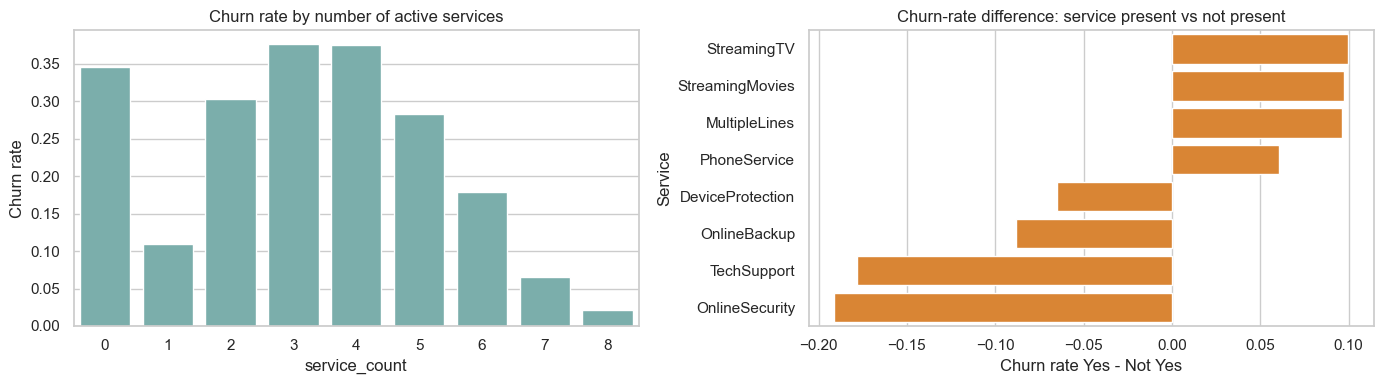

In [17]:
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )


train = pd.read_csv(data_dir / "train.csv")


target_candidates = [col for col in ["Churn", "churn", "target", "Target"] if col in train.columns]
target_col = target_candidates[0] if target_candidates else train.columns[-1]
target_numeric = train[target_col].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0, "1": 1, "0": 0, "true": 1, "false": 0})
if target_numeric.isna().all():
    target_numeric = pd.to_numeric(train[target_col], errors="coerce")
train = train.assign(_target=target_numeric)

service_cols = [col for col in [
    "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
] if col in train.columns]
if not service_cols:
    raise ValueError("No common service columns were found to create service_count.")

service_yes = train[service_cols].apply(lambda col: col.astype(str).str.strip().str.lower().eq("yes").astype(int))
train["service_count"] = service_yes.sum(axis=1)

service_count_summary = train.groupby("service_count")["_target"].agg(count="count", churn_rate="mean").reset_index()

service_effect_rows = []
for col in service_cols:
    has_service = train[col].astype(str).str.strip().str.lower().eq("yes")
    service_effect_rows.append({
        "service": col,
        "churn_rate_yes": train.loc[has_service, "_target"].mean(),
        "churn_rate_not_yes": train.loc[~has_service, "_target"].mean(),
        "gap_yes_minus_not_yes": train.loc[has_service, "_target"].mean() - train.loc[~has_service, "_target"].mean()
    })
service_effect = pd.DataFrame(service_effect_rows).sort_values("gap_yes_minus_not_yes", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=service_count_summary, x="service_count", y="churn_rate", ax=axes[0], color="#72B7B2")
axes[0].set_title("Churn rate by number of active services")
axes[0].set_ylabel("Churn rate")
sns.barplot(data=service_effect, y="service", x="gap_yes_minus_not_yes", ax=axes[1], color="#F58518")
axes[1].set_title("Churn-rate difference: service present vs not present")
axes[1].set_xlabel("Churn rate Yes - Not Yes")
axes[1].set_ylabel("Service")
plt.tight_layout()
plt.show()



* **Kết quả:**
  * **Xu hướng theo số lượng dịch vụ (`service_count`):** * Nhóm khách hàng không đăng ký thêm dịch vụ nào (`0`) có tỷ lệ rời đi rất cao (khoảng **35%**). Đáng chú ý, tỷ lệ này giảm mạnh ở mốc `1` dịch vụ, nhưng lại bật tăng tạo thành "đỉnh nguy cơ" mới tại mốc `3` và `4` dịch vụ (đều vượt ngưỡng **35%**).
    * Khi hệ sinh thái tích hợp từ `5` dịch vụ trở lên, tỷ lệ rời bỏ lao dốc mạnh mẽ, đặc biệt khi dùng trọn gói cả `8` dịch vụ thì tỷ lệ churn chạm đáy tối thiểu (gần như **0%**).
  * **Tác động theo loại dịch vụ cụ thể:**
    * **Dịch vụ gây rủi ro gia tăng (Hiệu số dương):** Nhóm dịch vụ giải trí và thoại (`StreamingTV`, `StreamingMovies`, `MultipleLines`, `PhoneService`) có tỷ lệ churn khi đăng ký cao hơn hẳn so với khi không đăng ký (chênh lệch từ **$6\% \rightarrow 10\%$**).
    * **Dịch vụ neo giữ lòng trung thành (Hiệu số âm):** Nhóm dịch vụ bảo mật và hỗ trợ kỹ thuật (`OnlineSecurity`, `TechSupport`, `OnlineBackup`, `DeviceProtection`) chứng minh khả năng khóa chân khách hàng cực tốt. Khách hàng dùng `OnlineSecurity` có tỷ lệ rời đi thấp hơn nhóm không dùng tới gần **$20\%$** ($-0.19$).
* **Kết luận cho hệ thống:**
  * **Gợi ý Feature Engineering:**
    * **Tạo tính năng đếm dịch vụ chiến lược (Strategic Service Count):** Thay vì chỉ đếm tổng số dịch vụ chung chung, ta tạo một đặc trưng đếm riêng cho cụm dịch vụ bảo mật/kỹ thuật: `utility_services_count = train[['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']].eq('Yes').sum(axis=1)`. Biến này sẽ mang tín hiệu giữ chân tuyến tính rất mạnh cho mô hình.
    * **Mã hóa phân khúc gánh nặng chi phí (Cost Burden Flag):** Mốc đỉnh nguy cơ `service_count` từ $3 \rightarrow 4$ phối hợp với các dịch vụ giải trí (`Streaming`) là tín hiệu của nhóm khách hàng đang phải chịu cước phí cao nhưng dễ thay thế dịch vụ. Có thể tạo biến tương tác: `is_vulnerable_combo = ((service_count >= 3) & (service_count <= 4) & (StreamingTV == 'Yes')).astype(int)`.

## 14. Kiểm tra tính nhất quán của hệ thống dịch vụ (Service Logic Consistency Checks)

### Mục đích
* Xác thực tính hợp lệ mang tính logic chéo (Cross-feature logic) giữa các dịch vụ cốt lõi (`InternetService`, `PhoneService`) và các dịch vụ bổ trợ đi kèm (như bảo mật, truyền hình, đa đường dây).
* Rà soát các lỗi phi lý về mặt giá trị số (`tenure < 1`, chi phí `≤ 0`) nhằm đảm bảo tập dữ liệu không tồn tại mâu thuẫn hệ thống trước khi tiến hành xây dựng các mô hình dự báo.

In [ ]:
# Service consistency checks
candidate_dirs = []
if Path.cwd().name.lower() == "eda":
    candidate_dirs.append(Path.cwd().parent / "data")
candidate_dirs.extend([
    Path.cwd() / "data",
    Path("data"),
    Path("../data"),
])
data_dir = next((p.resolve() for p in candidate_dirs if (p / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Put Kaggle files in repo data/ or run the optional download cell."
    )
train = pd.read_csv(data_dir / "train.csv")

internet_dependent_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]
phone_dependent_cols = ["MultipleLines"]

checks = {
    "tenure_less_than_1": int((train["tenure"] < 1).sum()),
    "monthly_charges_non_positive": int((train["MonthlyCharges"] <= 0).sum()),
    "total_charges_non_positive": int((train["TotalCharges"] <= 0).sum()),
    "internet_no_but_service_not_no_internet": int(
        train.loc[train["InternetService"].eq("No"), internet_dependent_cols]
        .ne("No internet service")
        .any(axis=1)
        .sum()
    ),
    "internet_yes_but_service_no_internet": int(
        train.loc[~train["InternetService"].eq("No"), internet_dependent_cols]
        .eq("No internet service")
        .any(axis=1)
        .sum()
    ),
    "phone_no_but_multiple_lines_not_no_phone": int(
        train.loc[train["PhoneService"].eq("No"), phone_dependent_cols]
        .ne("No phone service")
        .any(axis=1)
        .sum()
    ),
    "phone_yes_but_multiple_lines_no_phone": int(
        train.loc[train["PhoneService"].eq("Yes"), phone_dependent_cols]
        .eq("No phone service")
        .any(axis=1)
        .sum()
    ),
}

display(pd.Series(checks).to_frame("rows"))


,rows
tenure_less_than_1,0
monthly_charges_non_positive,0
total_charges_non_positive,0
internet_no_but_service_not_no_internet,0
internet_yes_but_service_no_internet,0
phone_no_but_multiple_lines_not_no_phone,0
phone_yes_but_multiple_lines_no_phone,0



* **Kết quả:**
  * **Lỗi biến số cực biên:** Toàn bộ các phép đếm `tenure_less_than_1`, `monthly_charges_non_positive` và `total_charges_non_positive` đều trả về kết quả bằng **0**.
  * **Mâu thuẫn dịch vụ mạng và thoại:** Tất cả các chỉ số kiểm tra logic chéo giữa dịch vụ chính và phụ (như `internet_no_but_service_not_no_internet` hay `phone_no_but_multiple_lines_not_no_phone`...) đều bằng **0**.
* **Kết luận cho hệ thống:**
  * **Xác thực độ sạch dữ liệu:** Kết quả đồng loạt bằng `0` chứng minh tập dữ liệu thô cực kỳ nhất quán, không bị dính các bản ghi lỗi logic (ví dụ: không có trường hợp vô lý như khách hàng không đăng ký Internet nhưng lại được ghi nhận là có dùng gói bảo mật mạng `OnlineSecurity`).
  * **Định hướng Feature Engineering:** * Vì logic dữ liệu hoàn toàn đồng bộ, không cần phải viết thêm các hàm xử lý ngoại lệ hay gán lại nhãn (Imputation) để sửa lỗi mâu thuẫn dịch vụ.
    * Khi thực hiện mã hóa **One-Hot Encoding** cho các biến dịch vụ bổ trợ, việc các nhóm "No internet service" hay "No phone service" có logic trùng khớp tuyệt đối với nhóm "No" của dịch vụ chính sẽ tạo ra các cột có độ tương quan hoàn hảo. Hệ thống hoàn toàn có thể tận dụng cấu trúc sạch này để tạo ra các biến phái sinh dạng gộp (Combo flags) mà không sợ bị lệch tín hiệu.

## Tổng kết các lưu ý cho feature engineering
### 1. Chiến lược Mã hóa Biến (Categorical Encoding)
* **Áp dụng One-Hot Encoding:** Tất cả các biến định tính đều có Cardinality rất thấp ($\le 4$ nhóm) và không chứa nhóm hiếm ($< 1\%$). Việc bung One-Hot Encoding là hoàn toàn an toàn, không lo bị bùng nổ chiều dữ liệu.
* **Xử lý nhãn tương đương:** Các nhãn mang tính chất phủ định như "No internet service" hay "No phone service" đã được chứng minh là nhất quán tuyệt đối với biến chính. Khi dùng One-Hot, các cột này sẽ mang tín hiệu giống hệt nhãn "No", giúp mô hình phân tách phân khúc rất rõ ràng.

### 2. Xử lý Đa cộng tuyến & Sàng lọc Đặc trưng (Feature Selection)
* **Loại bỏ biến số gây nhiễu (TotalCharges):** Biến này tương quan tuyến tính quá mạnh với tenure ($0.77$) và MonthlyCharges ($0.63$). Bạn nên loại bỏ TotalCharges hoặc áp dụng các mô hình có phạt (Lasso/Ridge) để tránh hiện tượng đa cộng tuyến làm sai lệch hệ số của mô hình tuyến tính.
* **Loại bỏ biến định tính yếu (gender):** Biên độ lệch tỷ lệ Churn của giới tính chỉ là 0.57% và độ tương quan gần như bằng 0. Hãy drop cột này để giảm nhiễu và tăng tốc độ huấn luyện.
* **Cân nhắc với PhoneService:** Biến này bị mất cân bằng cực hạn (nhóm Yes chiếm tới $93.89\%$). Hãy theo dõi sát sao, nếu khi đưa vào mô hình mà Feature Importance của nó quá thấp thì có thể loại bỏ.

### 3. Sửa lỗi Dữ liệu & Xử lý Outliers
* **Giới hạn trần/sàn (Winsorization) cho biến phái sinh:** Các biến bạn tính toán như `total_charge_gap` và `avg_charge_per_tenure` xuất hiện các giá trị max và min cực đoan bất thường do nhiễu dữ liệu thô. Hãy tiến hành clip dữ liệu tại mốc phân vị 1% và 99% để bảo vệ hàm mất mát của mô hình.
* **Biến đổi phân phối lệch (Log Transformation):** Biến TotalCharges (nếu giữ lại) và các biến chi phí có xu hướng lệch phải nặng. Hãy dùng `np.log1p()` để đưa chúng về phân phối chuẩn hơn.

### 4. Sáng tạo Đặc trưng Mới (Feature Construction)
* **Biến tương tác tích (charge_to_tenure_ratio):** Tính toán tỷ lệ `MonthlyCharges / (tenure + 1)` để đại diện cho áp lực chi phí trên một đơn vị thời gian. Chỉ số này càng cao càng tiến sát về vùng rủi ro rời đi $87.1\%$.
* **Cờ hiệu rủi ro cao (High-Risk Profile Flag):** Tạo biến nhị phân `is_high_risk_profile` kích hoạt bằng 1 nếu khách hàng rơi vào các cụm có tỷ lệ churn $> 40\%$:
  $$\text{Contract} = \text{'Month-to-month'} \quad \text{AND} \quad \text{PaymentMethod} = \text{'Electronic check'}$$
* **Cờ hiệu rời bỏ sớm (Early Churn Flag):** Kích hoạt khi `tenure <= 5` (dựa trên đỉnh phân phối của đồ thị KDE nhóm Yes).
* **Điểm số dịch vụ chiến lược (Strategic Service Score):** Tạo một biến đếm tổng các dịch vụ thuộc nhóm "neo giữ lòng trung thành":
  $$\text{utility\_services\_count} = \text{OnlineSecurity} + \text{TechSupport} + \text{OnlineBackup} + \text{DeviceProtection}$$
  *(Càng nhiều dịch vụ này, tỷ lệ Churn càng tiến về 0%).*
* **Gộp cụm giải trí:** Tích hợp `StreamingTV` và `StreamingMovies` (do tương quan nội bộ lên tới $0.66$) thành một biến đếm `streaming_count` từ 0 đến 2 nhằm giảm chiều dữ liệu.

### 5. Chiến lược Xác thực (Validation Strategy)
* Do dữ liệu Train/Test không bị dịch chuyển phân phối (No Data Drift), bạn có thể tự tin áp dụng Stratified K-Fold Cross-Validation ngay trên tập Train.
* Khi thực hiện các bước chuẩn hóa dữ liệu (như `StandardScaler` hay `MinMaxScaler`), bạn có thể lấy tham số (Mean, Std) từ tập Train để áp dụng trực tiếp cho tập Test một cách an toàn.

### 6. Xử lý Tương quan nội bộ giữa các Biến Định tính (Categorical Inter-Correlation)
* **Dựa trên phân tích heatmap tương quan giữa các biến định tính cơ bản:**
  * Nhóm biến dịch vụ bổ trợ Internet (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`) có tương quan nội bộ khá cao với nhau ($0.3$ – $0.5$). Khi mã hóa thành biến số, sự dư thừa thông tin này có thể ảnh hưởng đến hiệu năng mô hình.
  * **Gợi ý:** Ngoài việc tạo biến `utility_services_count` (đã nêu ở Mục 4), cân nhắc **loại bỏ các biến gốc** sau khi tạo biến tổng hợp để giảm nhiễu đa cộng tuyến cho các mô hình tuyến tính.
  * Tương tự, cặp `Partner` – `Dependents` có tương quan thuận đáng kể. Có thể tạo biến tổng hợp `has_family = (Partner == 1) OR (Dependents == 1)` nếu cần giảm chiều dữ liệu.

### 7. Xử lý biến `InternetService` và `Contract` (Biến đa nhóm - Multi-class Categorical)
* Hai biến `InternetService` (3 nhóm) và `Contract` (3 nhóm) là những biến có **lực phân tách Churn mạnh nhất** trong toàn bộ phân tích (spread > 40 percentage points).
* **Gợi ý:**
  * Với `Contract`: Cân nhắc tạo biến nhị phân `is_month_to_month` vì nhóm "Month-to-month" có tỷ lệ churn vượt trội so với hai nhóm còn lại (42% vs ~1-3%).
  * Với `InternetService`: Tạo biến nhị phân `is_fiber_optic` vì nhóm "Fiber optic" có tỷ lệ churn cao nhất (41.5%), trong khi "No" gần như không churn (1.4%).

### 8. Lưu ý về Phân phối Biến Mục tiêu (Target Imbalance)
* Biến mục tiêu `Churn` có tỷ lệ mất cân bằng đáng kể: **77.5% No** vs **22.5% Yes**.
* **Gợi ý:**
  * Không nên dùng Accuracy làm metric đánh giá chính. Ưu tiên sử dụng **ROC-AUC**, **PR-AUC**, **F1-Score (macro/weighted)** hoặc **Recall** tùy theo mục tiêu kinh doanh.
  * Cân nhắc áp dụng kỹ thuật **class weighting** (ví dụ: `class_weight='balanced'` trong Logistic Regression/Random Forest) hoặc **oversampling/undersampling** (SMOTE, Random Under-Sampling) nếu mô hình thiên vị quá nhiều về lớp đa số.
